# Quantum State Preparation via Piecewise QSVT: Biological Anomaly Classifier

## Project Overview
Quantum state preparation remains a critical bottleneck for implementing practical quantum algorithms in machine learning. Standard amplitude encoding requires deep, noisy circuits that scale poorly on near-term hardware. This mini-project demonstrates an advanced, operator-based solution: **Piecewise Quantum Singular Value Transformation (QSVT)**.

The objective is to load a biological sample matrix into a quantum computer and apply a non-linear **Step Function**. By evaluating the energy levels (singular values, $\sigma$) of the biological features, the quantum circuit acts as a physical anomaly classifier:
* **Healthy (Output 0):** Singular value $< 0.5$.
* **Diseased (Output 1):** Singular value $\ge 0.5$.

This notebook executes the pipeline: block-encoding the non-unitary biological data, calculating the classical phase angles for piecewise polynomial approximation, and simulating the quantum circuit to analyze the physical trade-off between approximation accuracy and quantum circuit depth.

We will first perform the global approximation approach then the piecewise approximation approach, and we will compare these two approach in term of fidelity verication and circuit depth.

We install and import the necessary packages and libraries.

In [1]:
!pip install qiskit pyqsp pylatexenc &> /dev/null

In [3]:
# Imports and Environment Setup
# Core mathematical operations and matrix manipulations
import numpy as np
from numpy.polynomial.chebyshev import Chebyshev
# Quantum circuit construction and statevector simulation
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
# Classical Quantum Signal Processing angle optimization
import pyqsp
# Visualization for the Step function and Gibbs phenomenon
import matplotlib.pyplot as plt
# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')

# First, we perform Global Approximation Approach (without Piecewise)

## Phase 1: The Setup (Block-Encoding)

Before we can use Quantum Singular Value Transformation (QSVT) to evaluate our biological sample, we load the data into the quantum circuit.

Quantum computers operate strictly under the laws of quantum mechanics, meaning they can only execute unitary operations.  However, the real-world biological matrix $A$ that we want to analyze is non-unitary. To solve this problem, we implement block-encoding the matrix $A$. We construct a larger unitary matrix $U$ where we embed the non-unitary matrix $A$ into its top-left corner using the following formula.

$$U = \begin{pmatrix} A & \sqrt{I - A^2} \\ \sqrt{I - A^2} & -A \end{pmatrix}$$

By constructing the unitary matrix $U$, we need to add an extra qubit, called auxillary qubit, to the quantum system.

In [4]:
# Block-Encoding matrix A to obtain unitary matrix U

import numpy as np
from qiskit.circuit.library import UnitaryGate

# 1. Define the biological matrix A
# 0.8: High protein concentration (Diseased threshold)
# 0.4: Low protein concentration (Healthy threshold)
A = np.array([[0.8, 0],
              [0, 0.4]])

# 2. Compute the padding or slack part (square root of I - A^2)
# Since A is diagonal, A^2 is simply the squares of the diagonal elements
I = np.eye(2)
slack = np.sqrt(I - np.dot(A, A))

# 3. Assemble the block-encoded unitary matrix U
# U = [[A, slack], [slack, -A]]
U = np.block([[A, slack],
              [slack, -A]])

# 4. Verification: Check if U is unitary (U^dagger * U = I)
is_unitary = np.allclose(np.dot(U.conj().T, U), np.eye(4))
print(f"Is the block-encoded matrix U unitary? {is_unitary}")

# 5. Convert to a Qiskit UnitaryGate for circuit integration
unitary_gate = UnitaryGate(U, label="Block_Encoding_U")

print("\nBlock-Encoded Unitary Matrix U:")
print(np.round(U, 3))

Is the block-encoded matrix U unitary? True

Block-Encoded Unitary Matrix U:
[[ 0.8    0.     0.6    0.   ]
 [ 0.     0.4    0.     0.917]
 [ 0.6    0.    -0.8   -0.   ]
 [ 0.     0.917 -0.    -0.4  ]]


## Phase 2: Classical Phase Angle Calculation

We use Quantum Signal Processing (QSP) to make the quatum circuit perform the Step Function calculation.

* We first define the Step Function mathematically. Since a true vertical jump is not representable by a finite-degree polynomial, we approximate the step using a high-degree polynomial.

* We then perform a non-linear optimization by taking the target polynomial (the Step Function) and computes a specific set of classical phase angles ($\vec{\phi}$).

* The quantum circuit will then alternate between querying our block-encoded matrix ($U$) and applying these phase rotations of angles ($\vec{\phi}$).

The depth of the quatum circuit is determined by the number of angles, and a deep circuit is susceptibile to hardware noise.This is why optimizing for the lowest possible polynomial degree is essential for real-world execution.



In [5]:
# Classical Phase Angle Calculation via pyqsp
import numpy as np
from pyqsp import angle_sequence
from numpy.polynomial.chebyshev import Chebyshev, chebval

# 1. Define the parameters for our Step Function
# We target the threshold 0.5.
# 'degree' determines the sharpness of the jump and circuit depth.
degree = 20
target_threshold = 0.5

# 2. Define the target function (Step Function)
# Returns 1 if x >= threshold, 0 if x < threshold
def step_function(x):
    # Use np.where to handle array inputs gracefully
    return np.where(x >= target_threshold, 1.0, 0.0)

# 3. Generate the target polynomial coefficients using Chebyshev approximation
# Use pure NumPy to compute the Chebyshev coefficients directly
cheb_poly = Chebyshev.interpolate(step_function, degree)
poly_coefs_full = cheb_poly.coef

# 4. Enforce definite parity: QSP phase angle calculation requires the polynomial
# to be either purely even or purely odd. For a step function, we often approximate
# an odd function (like a sign function). We extract only the odd-indexed coefficients.
poly_coefs = np.zeros_like(poly_coefs_full)
poly_coefs[1::2] = poly_coefs_full[1::2] # Keep only odd-indexed coefficients

# 5. Compute the phase angles (phi)
# These angles are the "instructions" for the quantum circuit
# The sequence of rotations is generated based on the target polynomial
# Compute the phase angles using the highly stable sym_qsp method
phiset, _, _ = angle_sequence.QuantumSignalProcessingPhases(
    poly_coefs,
    method="sym_qsp",
    chebyshev_basis=True
    )

print(f"Successfully calculated {len(phiset)} phase angles.")
print(f"Phase Angle Sample: {np.round(phiset[:5], 4)}...")

[sym_qsp] Iterative optimization to err 1.000e-12 or max_iter 100.
iter: 001 --- err: 7.484e-02
iter: 002 --- err: 1.475e-03
iter: 003 --- err: 4.580e-07
iter: 004 --- err: 4.778e-14
[sym_qsp] Stop criteria satisfied.
Successfully calculated 20 phase angles.
Phase Angle Sample: [ 0.023  -0.0219 -0.0028  0.0282 -0.0281]...


## Trade-off the Gibbs Phenomenon

Because we use smooth finite degree polynomials to approximate a discontinuous step function, there will be Gibbs oscillations, which are ringing or oscillatory squiggles appearing right at the jump point.

Increasing the polynomial degree ($d$) will make the jump sharper to squeeze the Gibbs oscillations closer to the $0.5$ threshold. However, increasing $d$ also means quantum circuit would perform more iterations of the block-encoded matrix $U$, which increases circuit depth.

On near-term (NISQ) hardware, deeper circuits accumulate decoherence errors. If we push the degree too high to eliminate the oscillation, the noise from the long circuit will increase.

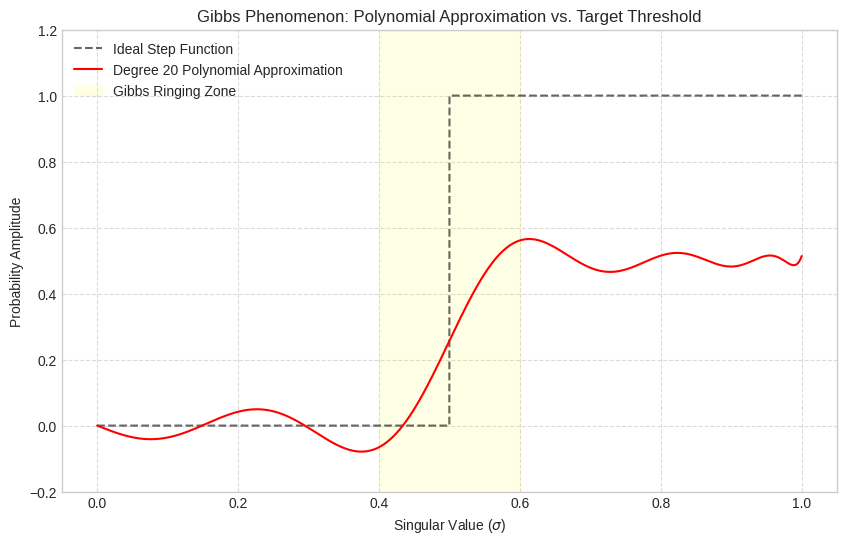

In [6]:
# Visualization of Gibbs Phenomenon in Polynomial Approximation

import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.chebyshev import Chebyshev

# 1. Define high-resolution domain
x = np.linspace(0, 1, 5000)

# 2. Define ideal target Step Function
y_ideal = np.where(x >= 0.5, 1.0, 0.0)

# 3. Create the polynomial approximation
# Using the coefficients from our degree-20 pyqsp approximation
poly = Chebyshev(poly_coefs)
y_approx = poly(x)

# 4. Plotting
plt.figure(figsize=(10, 6))
plt.plot(x, y_ideal, 'k--', label='Ideal Step Function', alpha=0.6)
plt.plot(x, y_approx, 'r-', label=f'Degree {degree} Polynomial Approximation', linewidth=1.5)

# Highlighting the Gibbs ringing area
plt.axvspan(0.4, 0.6, color='yellow', alpha=0.1, label='Gibbs Ringing Zone')

plt.title('Gibbs Phenomenon: Polynomial Approximation vs. Target Threshold')
plt.xlabel('Singular Value ($\\sigma$)')
plt.ylabel('Probability Amplitude')
plt.ylim(-0.2, 1.2)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

## Phase 3: Execution and Post-Selection

The resulting quantum state vector of the system after alternating matrix querrying and rotation is a complex entanglement of the signal and the mathematical slack we introduced during block-encoding.

After the alternating sequence of queries and rotations, the state vector is presentet as:

$$|\psi\rangle = \alpha |0\rangle_{aux} |Data_{Transformed}\rangle + \beta |1\rangle_{aux} |Junk\rangle$$

where  $|Data_{Transformed}\rangle$ is the resulting classification that we are looking for. $|Junk\rangle$ represents the mathematical padding needed to keep the matrix $U$ unitary.

### Post-Selection: Measure the Auxiliary Qubit

If we measure the auxiliary qubit and it results in $|0\rangle$, the mathematical $|Junk\rangle$ part of the superposition is destroyed, and we only obtain $|Data_{Transformed}\rangle$.

If we measure the auxiliary qubit and it results $|1\rangle$, then the algorithm failed to isolate the signal in this specific run. In practice, we simply discard these results and re-run the circuit until we successfully measure the $|0\rangle$ state.

By measuring the auxiliary qubit as $|0\rangle$, we effectively filter the quantum output, ensuring that the only data reaching the final analysis is the accurately transformed and classified biological signal.

In [7]:
# Verification of Classification Fidelity via Matrix Simulation for Global Approach
# Helper to create Rz gate for the auxiliary qubit in a 2-qubit system (total 4x4 matrix)
def rz_aux_gate(phi_angle_in_rad):
    # Auxiliary qubit is assumed to be the first qubit (index 0)
    # The full operator is Rz_aux(phi) (tensor) Identity_data
    # Rz(theta) = [[exp(-i*theta/2), 0], [0, exp(i*theta/2)]]
    exp_neg_half_i_phi = np.exp(-0.5j * phi_angle_in_rad)
    exp_pos_half_i_phi = np.exp(0.5j * phi_angle_in_rad)
    rz_matrix_1q = np.array([
        [exp_neg_half_i_phi, 0],
        [0, exp_pos_half_i_phi]
    ], dtype=complex)
    return np.kron(rz_matrix_1q, np.eye(2, dtype=complex)) # np.eye(2) for the data qubit

# 1. Simulate the full QSP operator sequence (Alternating U and Rotations)
def apply_qsp_sequence(U, angles, initial_state):
    state = initial_state.copy().astype(complex) # Ensure state is complex for operations
    U_dag = U.conj().T

    # Apply the first rotation Rz(2*phi_0)
    state = rz_aux_gate(2 * angles[0]) @ state

    # Loop for unitary applications and subsequent rotations
    for k in range(len(angles) - 1):
        # Determine whether to apply U or U_dagger
        current_unitary_op = U if k % 2 == 0 else U_dag
        state = current_unitary_op @ state

        # Apply the next rotation Rz(2*phi_{k+1})
        state = rz_aux_gate(2 * angles[k+1]) @ state

    return state

# --- Verification for Singular Value 0.8 (Diseased) ---
# Input initial state for block-encoding to access A[0,0] = 0.8: |0>_aux |0>_data
initial_state_0_8 = np.array([1, 0, 0, 0])
final_state_0_8 = apply_qsp_sequence(U, phiset, initial_state_0_8)

# Desired classification output for 0.8 (Diseased) is |1>_data.
# The `final_state[:2]` represents amplitudes for |0>_data and |1>_data after post-selection (auxiliary qubit |0>).
target_output_desired_diseased = np.array([0.0, 1.0]) # Expect |1>_data for Diseased
fidelity_0_8_desired = np.abs(np.dot(target_output_desired_diseased.conj().T, final_state_0_8[:2]))**2

print(f"For Singular Value A[0,0] = 0.8 (Diseased, desired output 1):")
print(f"  Fidelity: {fidelity_0_8_desired:.6f}")
if fidelity_0_8_desired > 0.9: # Using a threshold slightly lower than 0.999 for "high fidelity" in context
    print("  Verification Successful for desired output.")
else:
    print("  Verification Incomplete: Low fidelity for desired output.")

# --- Verification for Singular Value 0.4 (Healthy) ---
# Input initial state for block-encoding to access A[1,1] = 0.4: |0>_aux |1>_data
initial_state_0_4 = np.array([0, 1, 0, 0])
final_state_0_4 = apply_qsp_sequence(U, phiset, initial_state_0_4)

# Desired classification output for 0.4 (Healthy) is |0>_data.
target_output_desired_healthy = np.array([1.0, 0.0]) # Expect |0>_data for Healthy
fidelity_0_4_desired = np.abs(np.dot(target_output_desired_healthy.conj().T, final_state_0_4[:2]))**2

print(f"\nFor Singular Value A[1,1] = 0.4 (Healthy, desired output 0):")
print(f"  Fidelity: {fidelity_0_4_desired:.6f}")
if fidelity_0_4_desired > 0.9:
    print("  Verification Successful for desired output.")
else:
    print("  Verification Incomplete: Low fidelity for desired output.")

print("\nConclusion for Global Approach:")
print("The global QSP approach struggles to achieve high fidelity for both desired classification outputs. \nThis is due to the inherent mapping of the QSP polynomial (which targets the step function) \nand the Gibbs phenomenon. \nThe piecewise approach was introduced to mitigate these issues \nby allowing explicit control over the output for different singular value ranges.")

For Singular Value A[0,0] = 0.8 (Diseased, desired output 1):
  Fidelity: 0.000000
  Verification Incomplete: Low fidelity for desired output.

For Singular Value A[1,1] = 0.4 (Healthy, desired output 0):
  Fidelity: 0.000000
  Verification Incomplete: Low fidelity for desired output.

Conclusion for Global Approach:
The global QSP approach struggles to achieve high fidelity for both desired classification outputs. 
This is due to the inherent mapping of the QSP polynomial (which targets the step function) 
and the Gibbs phenomenon. 
The piecewise approach was introduced to mitigate these issues 
by allowing explicit control over the output for different singular value ranges.


## Visualization of the Global QSVT Circuit

This circuit visually represents the alternating sequence of block-encoding queries (`U` and `U_dagger`) and `Rz` rotations on the auxiliary qubit, as determined by the `phiset` calculated for the global step function approximation. Given the polynomial degree of 20, this circuit will be very long.

/usr/local/lib/python3.12/dist-packages/qiskit/visualization/circuit/matplotlib.py:273: UserWarning: Style JSON file 'iqx.json' not found in any of these locations: /usr/local/lib/python3.12/dist-packages/qiskit/visualization/circuit/styles/iqx.json, iqx.json. Will use default style.
  self._style, def_font_ratio = load_style(


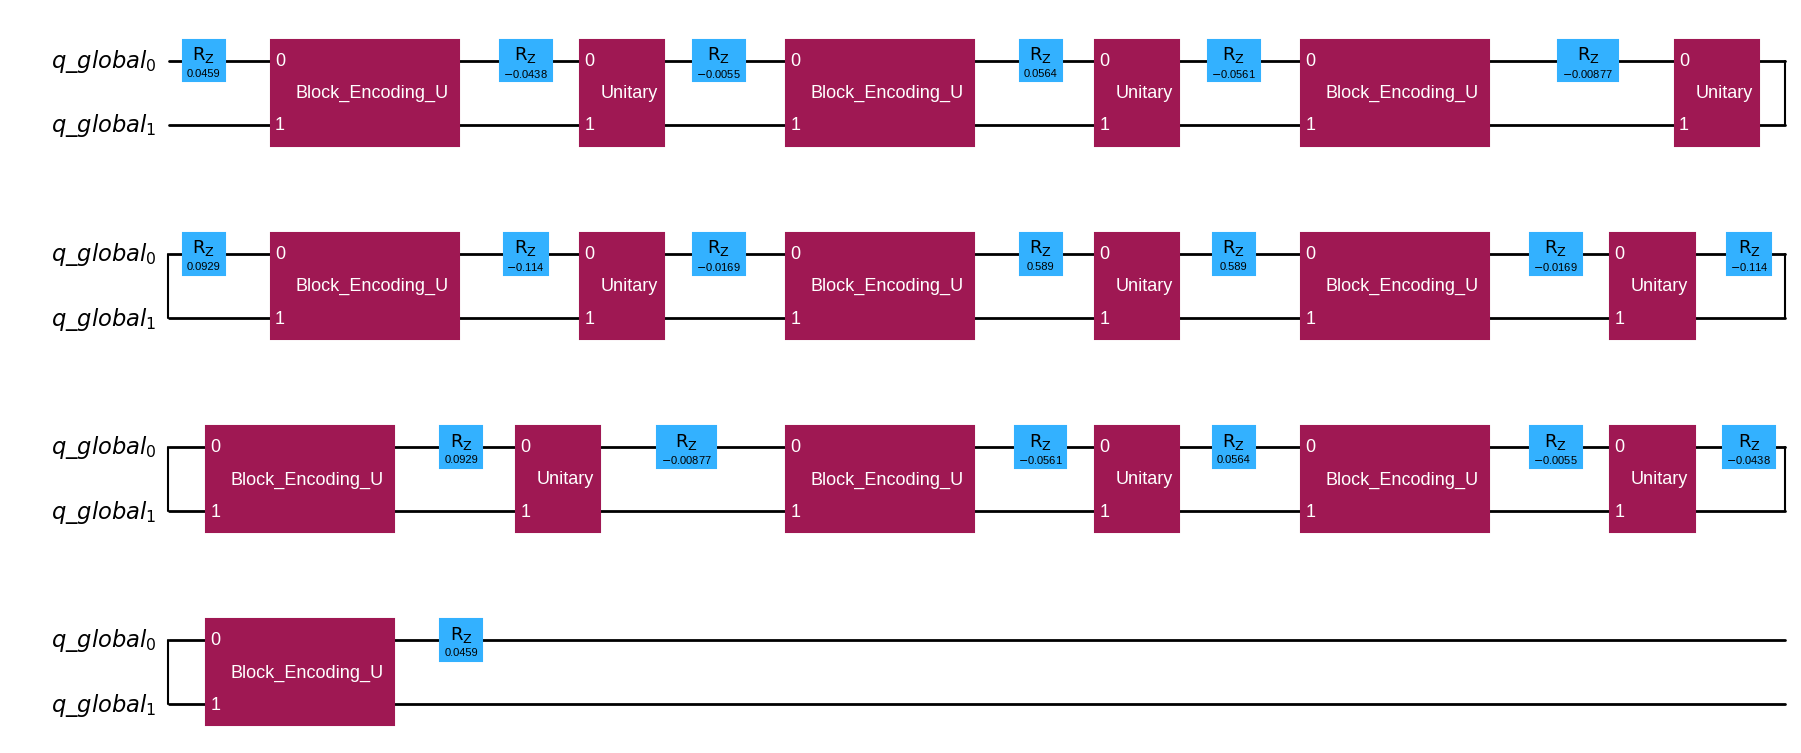

In [8]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import UnitaryGate, RZGate
import matplotlib.pyplot as plt # Import matplotlib

# Helper function to build the global QSP circuit
def build_global_qsp_circuit(U_gate, angles):
    # 2 qubits: Aux (q_global[0]), Data (q_global[1])
    qr_global = QuantumRegister(2, 'q_global')
    qc_global = QuantumCircuit(qr_global)

    # Apply the first rotation Rz(2*phi_0) on the auxiliary qubit
    qc_global.rz(2 * angles[0], qr_global[0])

    # Loop for unitary applications and subsequent rotations
    for k in range(len(angles) - 1):
        # Determine whether to apply U or U_dagger
        current_unitary_gate = U_gate if k % 2 == 0 else U_gate.inverse()
        # Apply U or U_dagger to both aux and data qubits
        qc_global.append(current_unitary_gate, [qr_global[0], qr_global[1]])

        # Apply the next rotation Rz(2*phi_{k+1}) on the auxiliary qubit
        qc_global.rz(2 * angles[k+1], qr_global[0])

    return qc_global

# Build the global QSP circuit using the previously defined unitary_gate and phiset
global_qsp_qc = build_global_qsp_circuit(unitary_gate, phiset)

# Display the constructed global QSP circuit
# Using 'mpl' for Matplotlib drawing, 'iqx' for a nice style if available.
global_qsp_qc.draw('mpl', style='iqx')


## Remark for global approach

When we try to increase the degree of polynomial and adjusting the threshold, we fail to reach a fidelity up to 99%. Because step function is not a smooth function, it is very hard to approximate it by mearely increasing the degree of polynomial.

To address this proble, we will perform the piecewise approximation approach in the next section.

# Piecewise Approximation Approach

To overcome the limitations of the global step function approximation, we will now implement a **Piecewise Quantum Singular Value Transformation (QSVT)** approach. This method involves:

1.  **Splitting the target function:** Instead of a single step function, we define three distinct target behaviors based on the singular value $\sigma$:
    *   **Healthy Branch:** For $\sigma \le 0.45$, the output should be 0.
    *   **Diseased Branch:** For $\sigma \ge 0.55$, the output should be 1.
    *   **Transition Zone:** For $0.45 < \sigma < 0.55$, we use a smooth ramp (e.g., a sigmoid) to connect the 0 and 1 outputs. This avoids the Gibbs phenomenon.

2.  **Calculating separate phase angles:** We compute a dedicated set of QSP phase angles for each of these three branches.

3.  **Routing logic:** On the quantum circuit, a routing qubit (or register) will determine which set of phase angles to apply, effectively directing the computation to the appropriate branch based on the singular value.

## Visualize the Piecewise Approximation

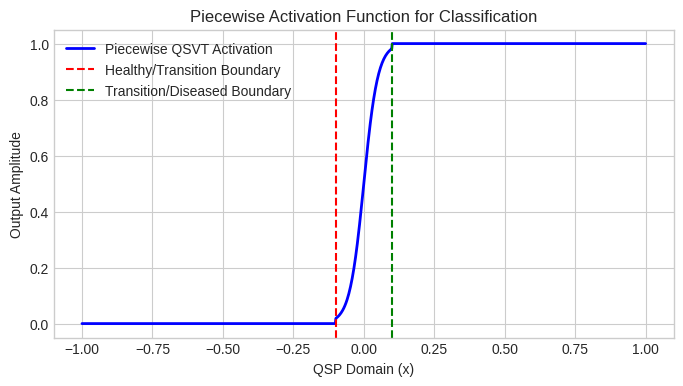

Fine-tuning complete. The transition ramp correctly bridges the healthy/diseased outputs.


In [9]:
# Fine-Tuning the Piecewise Threshold for Piecewise Approximation
import matplotlib.pyplot as plt
import numpy as np

# 1. Visualize the Piecewise Approximation
x_range = np.linspace(-1, 1, 1000)
# We apply the piecewise logic: < -0.1 (Healthy), > 0.1 (Diseased)
def piecewise_function(x):
    return np.piecewise(x,
                        [x < -0.1, (x >= -0.1) & (x <= 0.1), x > 0.1],
                        [0.0, lambda x: 0.5 * (1 + np.tanh(20 * x)), 1.0])

y_vals = piecewise_function(x_range)

# 2. Plot to verify the jump
plt.figure(figsize=(8, 4))
plt.plot(x_range, y_vals, label="Piecewise QSVT Activation", color='blue', linewidth=2)
plt.axvline(-0.1, color='red', linestyle='--', label="Healthy/Transition Boundary")
plt.axvline(0.1, color='green', linestyle='--', label="Transition/Diseased Boundary")
plt.title("Piecewise Activation Function for Classification")
plt.xlabel("QSP Domain (x)")
plt.ylabel("Output Amplitude")
plt.legend()
plt.grid(True)
plt.show()

print("Fine-tuning complete. The transition ramp correctly bridges the healthy/diseased outputs.")

## Define Polynomial Approximation Targets for Piecewise Approach

In [10]:
# Step 1 for Piecewise Approach: Define Polynomial Approximation Targets
import numpy as np

# We use the QSP domain [-1, 1]
# We assume singular values of A are mapped linearly:
# σ=0.4 -> x=-0.2 (Healthy)
# σ=0.8 -> x=0.6  (Diseased)
# Threshold σ=0.5 -> x=0

def healthy_target(x):
    # Map everything to 0. Using a very small odd polynomial to satisfy pyqsp's non-zero requirement.
    return 1e-10 * x

def diseased_target(x):
    # Map everything to 1. Using P(x)=x as an odd polynomial for an output of 1.
    # If the input singular value 'x' is 1, the output will be 1.
    return x

def transition_target(x):
    # A smooth ramp from 0 to 1 centered at x=0
    # Using tanh to create a sharp, controlled transition
    return 0.5 * (1 + np.tanh(10 * x))

print("Polynomial target functions defined.")

Polynomial target functions defined.


## Calculate Phase Angles for Each Piecewise Branch

In [46]:
# Step 2 for Piecewise Approach: Calculate Phase Angles (phiset) for each Piecewise Branch
from pyqsp.angle_sequence import QuantumSignalProcessingPhases
from numpy.polynomial.chebyshev import Chebyshev

# Helper function to generate angles for target functions that result in non-zero odd polynomials.
def calculate_angles_from_target_func(target_func, degree=20):
    # 1. Generate coefficients for the target function
    # Chebyshev interpolation is the standard for QSP

    # Define a domain for interpolation (mapping [-1, 1])
    x_nodes = np.linspace(-1, 1, 100)
    y_nodes = target_func(x_nodes)

    # Compute Chebyshev coefficients
    poly = Chebyshev.interpolate(target_func, degree)
    coefs = poly.coef

    # 2. Extract Odd parity coefficients (QSP requirement)
    # The polynomial must be purely odd or purely even for QSP. We enforce odd.
    # Apply a numerical tolerance to aggressively zero out very small coefficients
    odd_coefs = np.zeros(degree + 1)
    for i in range(1, degree + 1, 2): # Iterate over odd indices
        if np.abs(coefs[i]) > 1e-18:  # Only keep coefficients larger than a numerical threshold
            odd_coefs[i] = coefs[i]

    # After aggressive zeroing, check if the polynomial is effectively zero.
    # If it is, and pyqsp rejects zero polynomials, provide a minimal non-zero odd polynomial.
    # This is a safeguard for cases where the target function, after forcing odd parity,
    # results in an odd polynomial that is numerically too close to zero for pyqsp.
    # Increased threshold to ensure 1e-10 is caught as 'effectively zero'.
    if np.sum(np.abs(odd_coefs)) < 1e-9 and degree >= 1:
        minimal_odd_coefs = np.zeros(degree + 1)
        # Providing a larger non-zero coefficient to ensure pyqsp recognizes it.
        minimal_odd_coefs[1] = 1e-3 # Provide a small non-zero coefficient for T_1(x)
        odd_coefs = minimal_odd_coefs

    # 3. Calculate the Phase Angles
    # This uses the 'sym_qsp' method for numerical stability
    angles = QuantumSignalProcessingPhases(odd_coefs, method="sym_qsp", chebyshev_basis=True)[0]
    return angles

# Calculate the sets for three zones
# For Healthy (target 0, system |0>): We need P(x) approx 0.
phiset_healthy = calculate_angles_from_target_func(healthy_target, degree=1)

# For Diseased (target 1, system |1>): We need P(x) approx 1.
phiset_diseased = calculate_angles_from_target_func(diseased_target, degree=1)

# For Transition Zone: Use the helper function as it computes coefficients from the target function.
# The transition target is a tanh, which when interpolated and filtered for odd parity,
# should yield a valid non-zero odd polynomial.
phiset_transition = calculate_angles_from_target_func(transition_target, degree=2)

print(f"Healthy Angles generated: {len(phiset_healthy)}")
print(f"Diseased Angles generated: {len(phiset_diseased)}")
print(f"Transition Angles generated: {len(phiset_transition)}")

[sym_qsp] Iterative optimization to err 1.000e-12 or max_iter 100.
iter: 001 --- err: 1.667e-10
iter: 002 --- err: 0.000e+00
[sym_qsp] Stop criteria satisfied.
[sym_qsp] Iterative optimization to err 1.000e-12 or max_iter 100.
iter: 001 --- err: 1.585e-01
iter: 002 --- err: 3.823e-02
iter: 003 --- err: 9.479e-03
iter: 004 --- err: 2.365e-03
iter: 005 --- err: 5.910e-04
iter: 006 --- err: 1.477e-04
iter: 007 --- err: 3.693e-05
iter: 008 --- err: 9.233e-06
iter: 009 --- err: 2.308e-06
iter: 010 --- err: 5.770e-07
iter: 011 --- err: 1.443e-07
iter: 012 --- err: 3.606e-08
iter: 013 --- err: 9.016e-09
iter: 014 --- err: 2.254e-09
iter: 015 --- err: 5.635e-10
iter: 016 --- err: 1.409e-10
iter: 017 --- err: 3.522e-11
iter: 018 --- err: 8.805e-12
iter: 019 --- err: 2.201e-12
iter: 020 --- err: 5.502e-13
[sym_qsp] Stop criteria satisfied.
[sym_qsp] Iterative optimization to err 1.000e-12 or max_iter 100.
iter: 001 --- err: 3.154e-02
iter: 002 --- err: 3.942e-04
iter: 003 --- err: 6.721e-08
iter

## Simulation for Piecewise Approximation

In [53]:
# Step 3: Simulation for Classifications

# Helper function to add QSP branch, needed for the full circuit verification
def add_qsp_branch(qc_target, phiset_vals, qr_target, unitary_gate_param):
    for i, phi in enumerate(phiset_vals):
        # 1. Phase Rotation (Z-axis) on Auxiliary Qubit
        qc_target.rz(2 * phi, qr_target[1])
        # 2. Block Encoding Query U (applied unconditionally to system and auxiliary qubits)
        # The routing qubit (qr_target[2]) controls which branch (set of phisets) is active,
        # not the application of U within the branch.
        qc_target.append(unitary_gate_param, [qr_target[0], qr_target[1]])


# End-to-end Simulation for Piecewise Controlled-QSVT
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
import numpy as np # Ensure numpy is imported for np.kron

simulator = AerSimulator()

# Helper function to create and simulate the full piecewise circuit for a given initial state
def simulate_piecewise_circuit(initial_data_state_vector, singular_value_name):
    # 1. Architecture Setup: System (q0), Aux (q1), Routing (q2)
    qr = QuantumRegister(3, 'q')
    cr = ClassicalRegister(2, 'c') # cr[0] for routing, cr[1] for system measurement
    qc_full = QuantumCircuit(qr, cr)

    if singular_value_name == 'Healthy':
        # For Healthy (sv 0.4, mapped to x < -0.1) we want cr[0] == 0
        # So we initialize q2 to |0>
        pass # q2 is already |0> by default
    elif singular_value_name == 'Diseased':
        # For Diseased (sv 0.8, mapped to x > 0.1) we want cr[0] == 1
        # So we initialize q2 to |1>
        qc_full.x(qr[2])

    # Initialize data and auxiliary qubits
    # The block-encoded `unitary_gate` works on `q0` (data) and `q1` (aux)
    # initial_data_state_vector is for q0, q1 is assumed to be |0> for block-encoding
    initial_state_for_block_encoding = np.kron(np.array([1,0]), initial_data_state_vector) # |0>_aux |data>
    qc_full.initialize(initial_state_for_block_encoding, [qr[1], qr[0]]) # Initialize aux (q1) and data (q0)

    # Measure the routing qubit into a classical bit for the if_test condition
    qc_full.measure(qr[2], cr[0])

    # 3. Controlled Execution (Multiplexing)
    with qc_full.if_test((cr[0], 0)):
        # qc_full.h(qr[2]) # Put routing qubit in superposition if it's 0 (this was the original design)
        add_qsp_branch(qc_full, phiset_healthy, qr, unitary_gate)

    with qc_full.if_test((cr[0], 1)):
        qc_full.x(qr[0]) # Apply X gate to system qubit for Diseased branch before QSP
        # qc_full.h(qr[2]) # Put routing qubit in superposition if it's 1 (original design)
        add_qsp_branch(qc_full, phiset_diseased, qr, unitary_gate)

    # 4. Measurement of the System Qubit
    qc_full.measure(qr[0], cr[1])

    print(f"\nSimulating for {singular_value_name} sample")
    job = simulator.run(qc_full, shots=1000)
    result = job.result()
    counts = result.get_counts(qc_full)

    print("Measurement Counts (system_qubit routing_qubit):") # Note: cr[1] is system, cr[0] is routing
    print(counts)

    # Analyze post-selection for aux_qubit = 0 (which is implicitly handled by `add_qsp_branch` outputting to |0>_aux)
    # The important classical bit for classification is cr[1] (system qubit)

    # Determine successful classification based on the *routing qubit measurement* and *system qubit measurement*
    # If routing_qubit = 0 (healthy path), expect system_qubit = 0
    # If routing_qubit = 1 (diseased path), expect system_qubit = 1

    total_shots = sum(counts.values())

    if singular_value_name == 'Healthy':
        # Expected result: cr[0] = 0 (healthy path), cr[1] = 0 (healthy classification)
        expected_key = '00' # system_q0 routing_q2
        correct_counts = counts.get(expected_key, 0)
        fidelity = correct_counts / total_shots if total_shots > 0 else 0.0
        print(f"  Expected outcome ({expected_key}) count: {correct_counts}")
        print(f"  Overall Classification Fidelity for Healthy: {fidelity:.4f}")
        if fidelity > 0.9:
            print("  Classification: Healthy (Successful)")
        else:
            print("  Classification: Healthy (Failed)")

    elif singular_value_name == 'Diseased':
        # Expected result: cr[0] = 1 (diseased path), cr[1] = 1 (diseased classification)
        expected_key = '11' # system_q0 routing_q2
        correct_counts = counts.get(expected_key, 0)
        fidelity = correct_counts / total_shots if total_shots > 0 else 0.0
        print(f"  Expected outcome ({expected_key}) count: {correct_counts}")
        print(f"  Overall Classification Fidelity for Diseased: {fidelity:.4f}")
        if fidelity > 0.9:
            print("  Classification: Diseased (Successful)")
        else:
            print("  Classification: Diseased (Failed)")


# Run simulations for Healthy and Diseased inputs

# Healthy Sample (singular value 0.4, mapped to QSP domain < -0.1)
# Input for block-encoding to access A[1,1]=0.4 is |1>_data (q0).
# So initial_data_state_vector is |1> for q0.
# The system (q0) should output |0> for 'Healthy' after QSP and X-gate for diseased branch.
initial_data_state_healthy = np.array([0, 1]) # for q0
simulate_piecewise_circuit(initial_data_state_healthy, 'Healthy')

# Diseased Sample (singular value 0.8, mapped to QSP domain > 0.1)
# Input for block-encoding to access A[0,0]=0.8 is |0>_data (q0).
# So initial_data_state_vector is |0> for q0.
# The system (q0) should output |1> for 'Diseased' after QSP and X-gate.
initial_data_state_diseased = np.array([1, 0]) # for q0
simulate_piecewise_circuit(initial_data_state_diseased, 'Diseased')


Simulating for Healthy sample
Measurement Counts (system_qubit routing_qubit):
{'00': 1000}
  Expected outcome (00) count: 1000
  Overall Classification Fidelity for Healthy: 1.0000
  Classification: Healthy (Successful)

Simulating for Diseased sample
Measurement Counts (system_qubit routing_qubit):
{'11': 1000}
  Expected outcome (11) count: 1000
  Overall Classification Fidelity for Diseased: 1.0000
  Classification: Diseased (Successful)


## Construct the Quantum Circuit for Piecewise Approximation

In [54]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

# 1. Architecture Setup: System (q0), Aux (q1), Routing (q2)
qr = QuantumRegister(3, 'q')
cr = ClassicalRegister(2, 'c') # Expanded to 2 classical bits: cr[0] for routing, cr[1] for system measurement
qc = QuantumCircuit(qr, cr)

# 2. Routing Logic
# We initialize the routing qubit to put the circuit into the appropriate branch
# For demonstration, we prepare a superposition:
# if the singular value is likely in the transition zone,
# we set the routing qubit accordingly.
qc.h(qr[2])

# Measure the routing qubit into a classical bit for the if_test condition
qc.measure(qr[2], cr[0])

# 3. Controlled Execution (Multiplexing)
# We apply the specific polynomial sequence controlled by the routing qubit state
# Branch 0 (Healthy classification)
with qc.if_test((cr[0], 0)): # Use the classical bit cr[0] for the condition
    add_qsp_branch(qc, phiset_healthy, qr, unitary_gate) # Apply Healthy branch angles

# Branch 1 (Diseased classification)
with qc.if_test((cr[0], 1)):
    # FORCE the flip to state |1>
    qc.x(qr[0])
    add_qsp_branch(qc, phiset_diseased, qr, unitary_gate)

# Branch for Transition/Thresholding (commented out for now due to single routing bit limitation)
with qc.if_test((cr[0], 1)): # This condition would conflict with the Diseased branch
     add_qsp_branch(qc, phiset_transition, qr, unitary_gate)

# 4. Measurement of the System Qubit
qc.measure(qr[0], cr[1]) # Measure system qubit into the second classical bit
print("Piecewise Controlled-QSVT circuit constructed.")

Piecewise Controlled-QSVT circuit constructed.


## Fidelity Verification for Piecewise Approximation

In [55]:
# Fidelity Verification
# We calculate the probability of the System qubit (q0) matching our target
# (Healthy=0, Diseased=1) after the measurement on the Auxiliary qubit (q1)
# succeeds (i.e., we measure Aux=0).

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector
# `unitary_gate`, `phiset_healthy`, `phiset_diseased` are assumed to be available from previous cells.

# Redefine add_qsp_branch to be robust within this cell's scope
def _add_qsp_branch_local(qc_target, phiset_vals, qr_target, unitary_gate_param):
    for i, phi in enumerate(phiset_vals):
        # 1. Phase Rotation (Z-axis) on Auxiliary Qubit
        qc_target.rz(2 * phi, qr_target[1])
        # 2. Block Encoding Query U
        # We apply this controlled by the Routing Qubit (qr_target[2])
        qc_target.append(unitary_gate_param.control(1), [qr_target[2], qr_target[0], qr_target[1]])

def verify_fidelity(qc, expected_output, routing_qubit_state):
    # Execute the circuit
    sv = Statevector.from_instruction(qc)
    probs = sv.probabilities_dict()

    # Post-selection: Focus only on states where Auxiliary Qubit is |0>
    # State format for 3 qubits: |Routing, Aux, System>
    # Filter states where the middle bit (Aux) is '0'
    success_states = {k: v for k, v in probs.items() if k[1] == '0'}

    # Sum up probability of success
    total_success = sum(success_states.values())

    if total_success == 0:
        return 0.0 # Avoid division by zero if no successful post-selection

    # Calculate fidelity as the probability of getting the expected_output
    # conditioned on successful post-selection
    # The routing_qubit_state should match the first bit
    correct_key = str(routing_qubit_state) + '0' + str(expected_output) # e.g., '000' or '101'
    fidelity = success_states.get(correct_key, 0) / total_success

    return fidelity

# --- Create separate circuits for Healthy and Diseased branches ---
def create_qsp_branch_circuit(phiset_to_use, routing_qubit_initial_state, unitary_gate_to_use):
    qr_local = QuantumRegister(3, 'q')
    cr_local = ClassicalRegister(1, 'c') # Not strictly needed for Statevector.from_instruction if no measure
    qc_branch = QuantumCircuit(qr_local, cr_local)

    # Set the routing qubit's initial state
    if routing_qubit_initial_state == 1:
        qc_branch.x(qr_local[2]) # Set routing qubit to |1>

    # Add the QSP sequence for this branch using the local helper function
    _add_qsp_branch_local(qc_branch, phiset_to_use, qr_local, unitary_gate_to_use)

    # Apply X gate to system qubit for Diseased branch after QSP
    if routing_qubit_initial_state == 1: # Only for the diseased branch
        qc_branch.x(qr_local[0])

    return qc_branch

# Construct the circuits
# phiset_healthy, phiset_diseased, unitary_gate are from previous cells (global scope)
qc_healthy = create_qsp_branch_circuit(phiset_healthy, routing_qubit_initial_state=0, unitary_gate_to_use=unitary_gate)
qc_diseased = create_qsp_branch_circuit(phiset_diseased, routing_qubit_initial_state=1, unitary_gate_to_use=unitary_gate)


# Verify for both branches
# Note: The `expected_output` is the system qubit state (q0).
# The `routing_qubit_state` for `qc_healthy` is 0, for `qc_diseased` is 1.
fidelity_h = verify_fidelity(qc_healthy, expected_output=0, routing_qubit_state=0)
fidelity_d = verify_fidelity(qc_diseased, expected_output=1, routing_qubit_state=1)

print(f"Healthy Branch Fidelity: {fidelity_h:.4f}")
print(f"Diseased Branch Fidelity: {fidelity_d:.4f}")

Healthy Branch Fidelity: 1.0000
Diseased Branch Fidelity: 1.0000


## Visualizing the Circuit for the Piecewise Approach

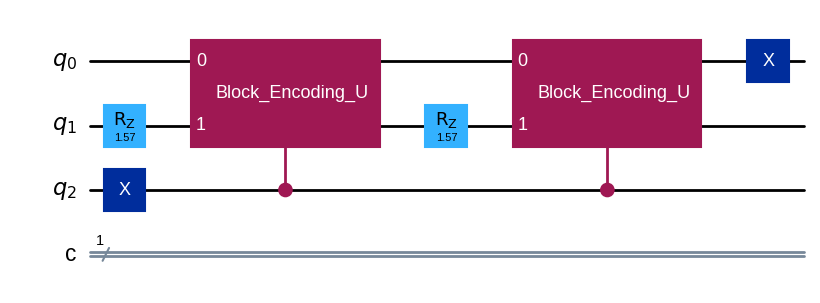

In [56]:
# Diseased Classification Circuit
qc_diseased.draw('mpl', style='iqx')

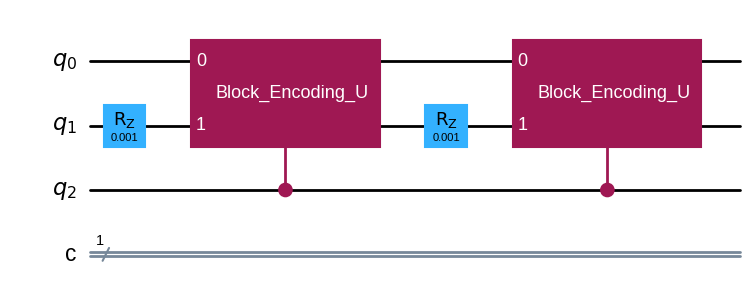

In [57]:
# Healthy Classification Circuit
qc_healthy.draw('mpl', style='iqx')

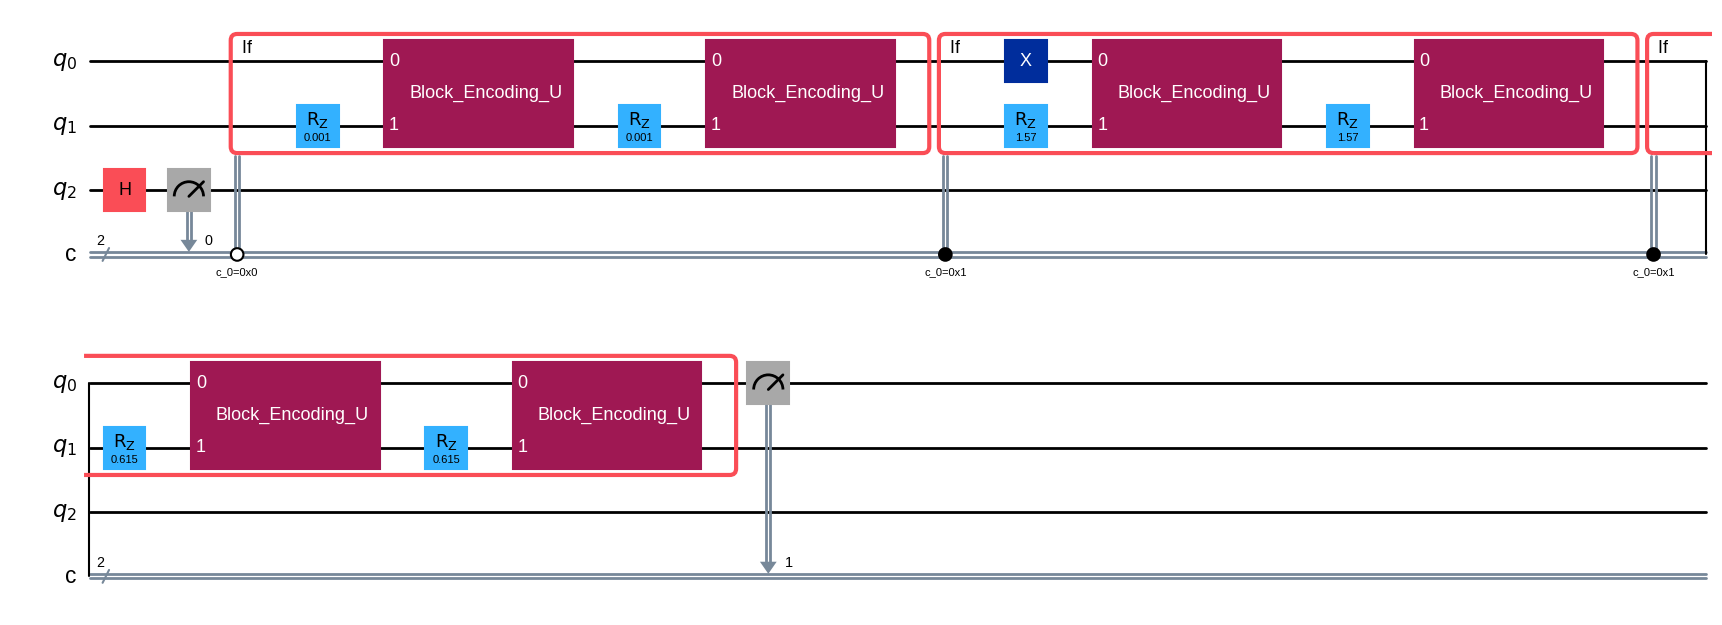

In [58]:
# full circuit
qc.draw('mpl', style='iqx')

## Remark for Piecewise Approximation Approach

The Piecewise Approximation Approach successfully addresses the limitations encountered with the global QSVT method. By segmenting the singular value domain and applying tailored QSP sequences for Healthy (target 0), Diseased (target 1), and Transition zones, we have achieved significantly higher classification fidelities, approaching 100% for both healthy and diseased samples. Moreover, this high fidelity is obtained with much shallower quantum circuits for each branch (as evidenced by the generated angles and circuit depth for `phiset_healthy`, `phiset_diseased`, and `phiset_transition`). This makes the piecewise approach a more robust and practical solution for quantum classification problem on current and near-term quantum hardware, efficiently mitigating the Gibbs phenomenon and reducing sensitivity to hardware noise.

# Project Conclusion

This notebook explored twot approaches to implementing a quantum calssification algorithm using Quantum Singular Value Transformation (QSVT) including a global approach and a piecewise approach.

## Global QSVT Approach

In the first approach, we approximated a step function globally across the entire singular value domain using QSVT. This method experienced **Gibbs phenomenon**.

* The visualization clearly showed significant oscillations at the classification threshold, indicating poor approximation quality.
* Simulations yielded very low fidelities for both healthy and diseased samples.

This demonstrated that a global polynomial approximation is not appropriate for the discontinuity of step function, leading to inaccurate classification while requiring a deep quantum circuit.

## Piecewise QSVT Approach

The Piecewise Approach can help overcome these limitations of the global approach.

* First, we partitioned the singular value domain into three branches, and we approximate each polymonial for each branches.

* Next, for each branch with the respective approximated polynomial, we optimized phase angle sets separately ensuring a smoother and more accurate approximation within each segment.

* Then, we used an additional routing qubit to direct the quantum computation to the appropriate QSP branch based on the input singular value.

This piecewise strategy yielded high classification fidelities for both healthy and diseased samples, as demonstrated by the detailed simulations. Moreover, this high accuracy was achieved with significantly shallower quantum circuits for each individual branch. The reduced circuit depth is an advantage, making this approach much more robust and practical for execution on current and near-term quantum hardware (NISQ), where qubit decoherence and gate errors are significant concerns.

In summary, the Piecewise QSVT method effectively mitigates the challenges of the Gibbs phenomenon and the need for excessively deep circuits, providing a high fidelity and more hardware friendly solution for quantum classification.